0
     PassengerId  Survived  Pclass  Sex       Age  SibSp  Parch  \
0              1         0       3    1 -0.530377      1      0   
1              2         1       1    0  0.571831      1      0   
2              3         1       3    0 -0.254825      0      0   
3              4         1       1    0  0.365167      1      0   
4              5         0       3    1  0.365167      0      0   
..           ...       ...     ...  ...       ...    ...    ...   
886          887         0       2    1 -0.185937      0      0   
887          888         1       1    0 -0.737041      0      0   
888          889         0       3    0       NaN      1      2   
889          890         1       1    1 -0.254825      0      0   
890          891         0       3    1  0.158503      0      0   

               Ticket      Fare Cabin  Family_size  IsAlone  Embarked_C  \
0           A/5 21171 -0.502445   NaN            1        1       False   
1            PC 17599  0.786845   C85      

TypeError: cannot unpack non-iterable NoneType object

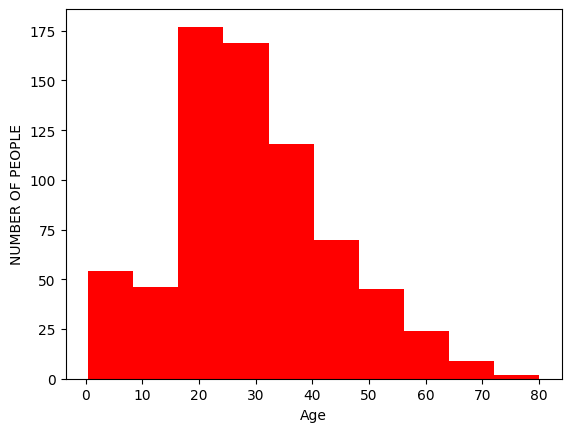

In [4]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
#!pip install seaborn

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
"C:/Users/Hp/OneDrive/Documents/Fax/Desktop/ml projects/titanic house price pediction/data/raw/Titanic-Dataset (1).csv"
)
#print(df.head())
#print(df.info())
#print(df.describe())
#print(df.isnull().sum())

#sns.heatmap(df.isnull(),cbar=True,cmap="magma")
#print(plt.show())

ages=df["Age"].dropna()

plt.hist(ages,bins=10,color="red")
plt.xlabel("Age")
plt.ylabel("NUMBER OF PEOPLE")
#plt.show()

df["Age"].median(),df["Age"].mean()
df["Age"]=df["Age"].fillna(df["Age"].median())
df.drop("Cabin",axis=1, inplace=True)
df.drop_duplicates(inplace=True)

#print(df.info())
print((df["Age"].isna().sum()))
import  pandas as pd  


def clean_data(df):
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df.drop("Cabin", axis=1, inplace=True)
    df.drop_duplicates(inplace=True)
   # return (df.info())

#clean_data(df)  




df['Family_size']=df["SibSp"]+df["Parch"]
#print(df.info())
df["Isalone"]=(df["Family_size"]==1).astype(int)
#print(df.info())
df["sex"]=LabelEncoder().fit_transform(df["Sex"])
df.drop("sex",axis=1, inplace=True)
#print(df.info())
df=pd.get_dummies(df,columns=["Embarked"])
df.drop("Name",axis=1,inplace=True)
df[["Age","Fare"]]= StandardScaler().fit_transform(df[["Age","Fare"]])
#print(df)



import sys 
import os
import pandas as pd

os.chdir(r"C:\Users\Hp\OneDrive\Documents\Fax\Desktop\ml projects\titanic house price pediction")
sys.path.append(os.getcwd())
from src.feature_engineering import preprocess_titanic 

# Load raw data
df = pd.read_csv(r"data/raw/Titanic-Dataset (1).csv")

# Apply preprocessing
df_clean = preprocess_titanic(df)


print(df_clean)  


"""
# Check
print(df_clean.columns)
from src.feature_engineering import preprocess_titanic
from src.visualize import visualize_data
#visualize_data(df)
#visualize_data(df_clean)
"""
 
from src.prepare_data import prepare_data

x_train, x_test, y_train, y_test = prepare_data(df)


from src.evaluate_model import evaluate_model
metrics = evaluate_model()

metrics["logistic"]["accuracy"]
metrics["decision_tree"]["f1"]